# 03 — Model Comparison

Train Linear Regression, Random Forest, and LSTM. Compare performance and analyse feature importance.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import load_processed, load_raw
from src.preprocessing import build_features
from src.model import (
    FEATURE_COLUMNS, split_data,
    train_linear_regression, train_random_forest, tune_random_forest,
    train_lstm, predict_lstm,
    save_model,
)
from src.evaluation import evaluate, print_metrics
from src.visualization import (
    plot_prediction, plot_model_comparison_3, plot_actual_vs_predicted,
    plot_residuals, plot_error_distribution, plot_lstm_loss,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Prepare data
try:
    df = load_processed()
    print('Loaded processed data')
except FileNotFoundError:
    print('Processed data not found; building from raw...')
    df = build_features(load_raw())

Loaded processed data


In [3]:
# Train / test split
X_train, X_test, y_train, y_test = split_data(df)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS[:5]} ...')

Train: (150961, 24), Test: (37741, 24)
Features (24): ['Speed', 'RSRP', 'RSRQ', 'SNR', 'CQI'] ...


[LinearRegression] RMSE=28931.7921  MAE=13036.1300  R2=0.7993


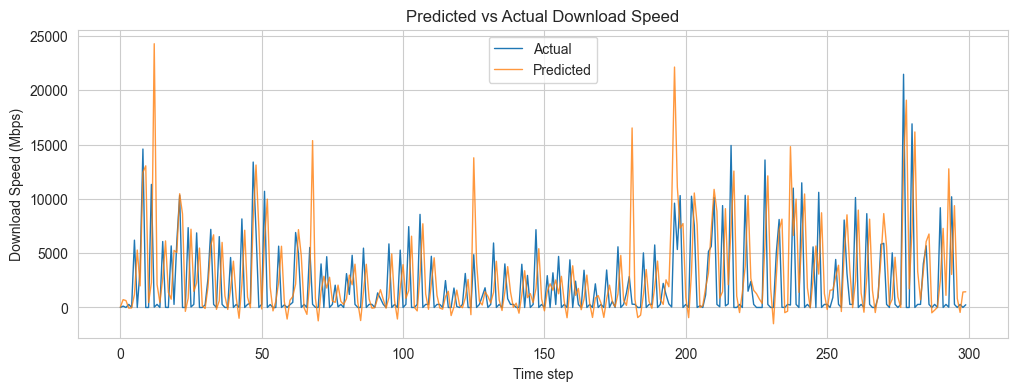

In [4]:
# Linear Regression
lr = train_linear_regression(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_metrics = evaluate(y_test, lr_preds)
print_metrics('LinearRegression', lr_metrics)
plot_prediction(y_test, lr_preds)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2: 0.4065
[RandomForest] RMSE=19572.4211  MAE=8071.3657  R2=0.9081


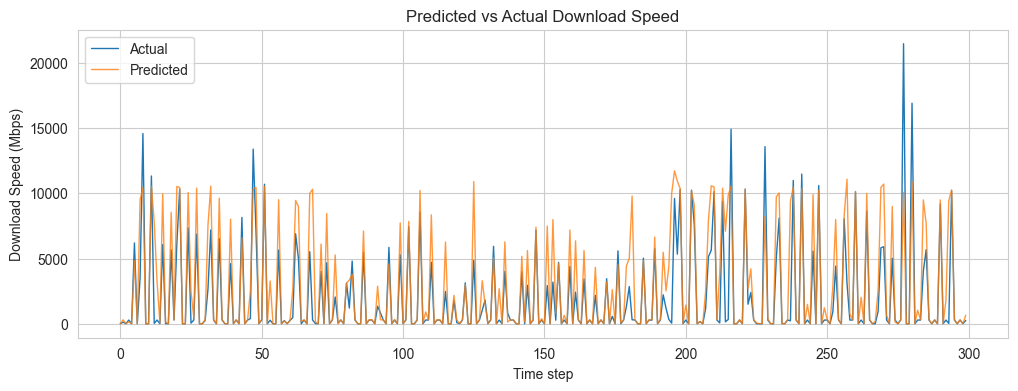

In [5]:
# Random Forest (with tuning)
rf = tune_random_forest(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_metrics = evaluate(y_test, rf_preds)
print_metrics('RandomForest', rf_metrics)
plot_prediction(y_test, rf_preds)

  Epoch   1/100  train_loss=0.5233  val_loss=0.1478


  Epoch  10/100  train_loss=0.1884  val_loss=0.1185


  Epoch  20/100  train_loss=0.1316  val_loss=0.1642


  Epoch  30/100  train_loss=0.0985  val_loss=0.1391


  Early stopping at epoch 32 (best val_loss=0.1063)


[LSTM] RMSE=50837.9927  MAE=23687.9551  R2=0.3807


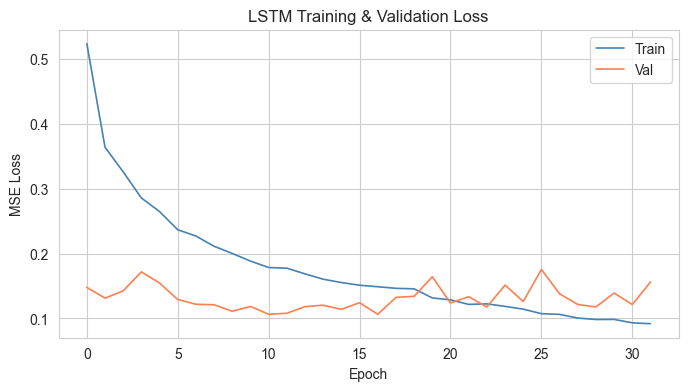

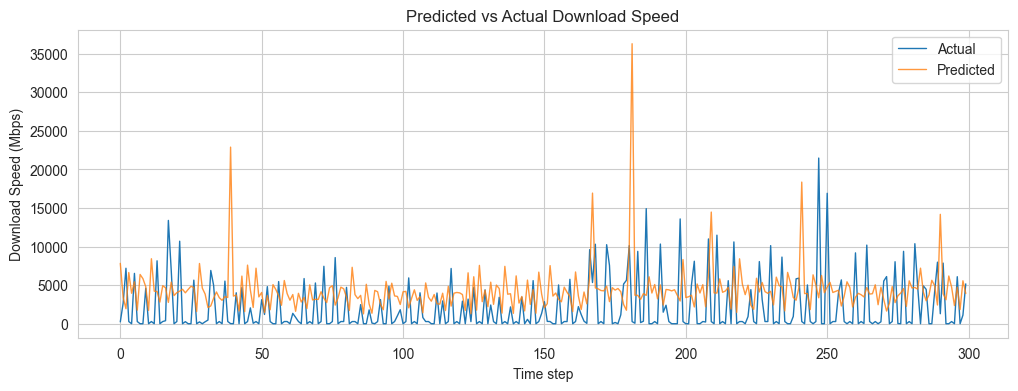

In [6]:
# LSTM (using feature set without pre-computed lag/rolling)
X_train_lstm = X_train[config.LSTM_FEATURE_COLUMNS]
X_test_lstm = X_test[config.LSTM_FEATURE_COLUMNS]
lstm_model, lstm_scaler, lstm_y_scaler, lstm_losses, lstm_val_losses, y_test_lstm = train_lstm(
    X_train_lstm, y_train, X_test_lstm, y_test
)
lstm_preds = predict_lstm(lstm_model, lstm_scaler, X_test_lstm, y_scaler=lstm_y_scaler)
lstm_metrics = evaluate(y_test_lstm, lstm_preds)
print_metrics('LSTM', lstm_metrics)

plot_lstm_loss(lstm_losses, lstm_val_losses)
plot_prediction(y_test_lstm, lstm_preds)

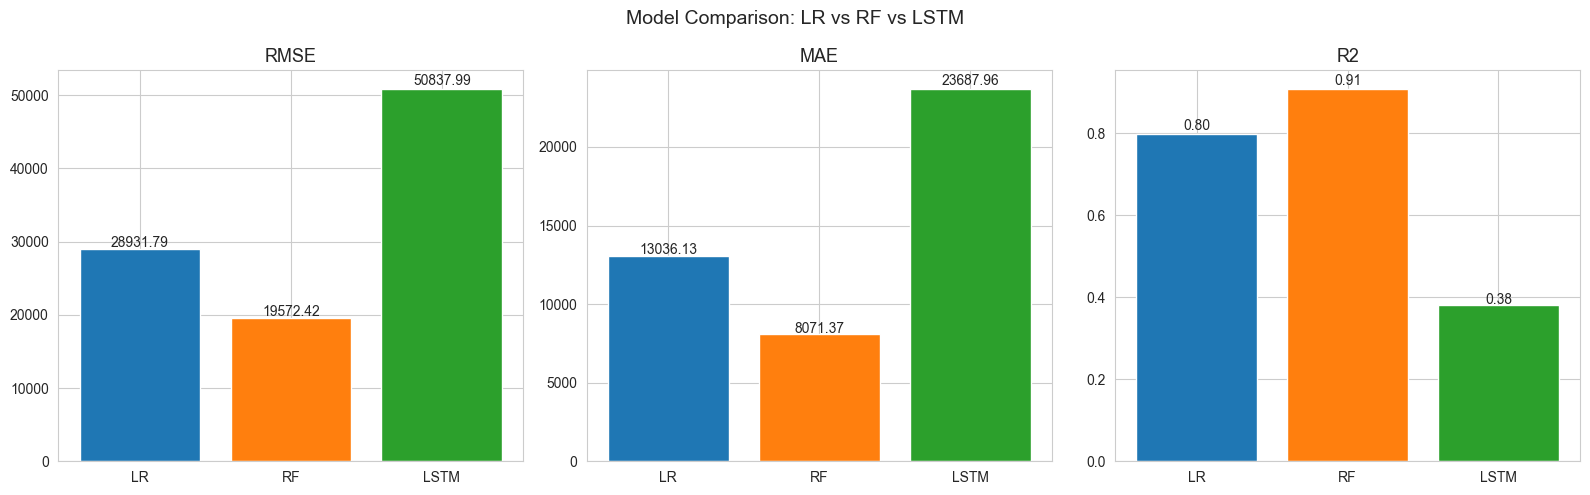

In [7]:
# 3-model comparison
plot_model_comparison_3(lr_metrics, rf_metrics, lstm_metrics)

Text(0.5, 1.0, 'RF Feature Importance')

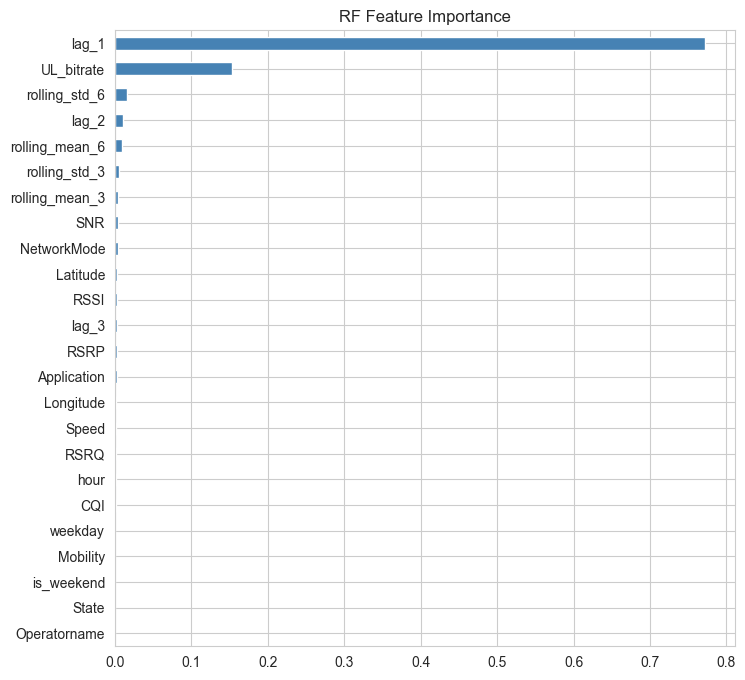

In [8]:
# Random Forest feature importance
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
ax = imp.plot(kind='barh', figsize=(8, 8), color='steelblue')
ax.set_title('RF Feature Importance')

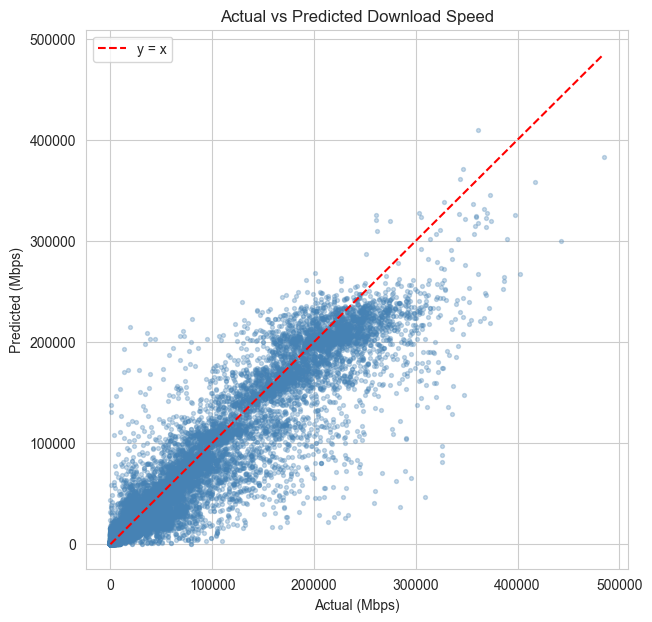

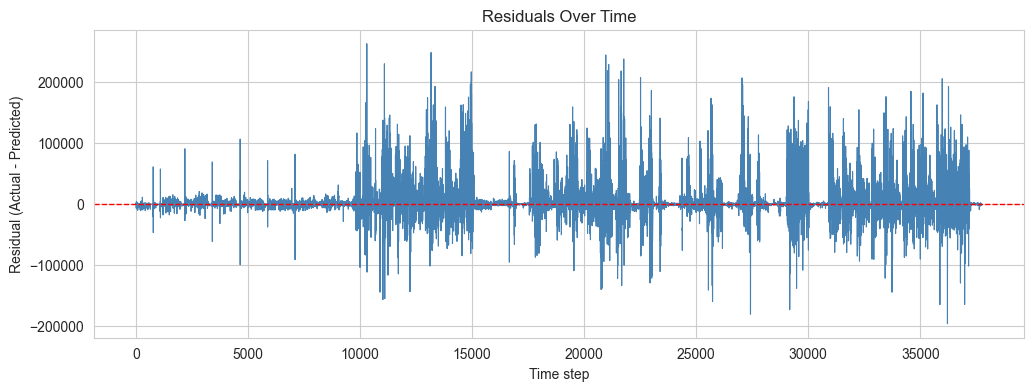

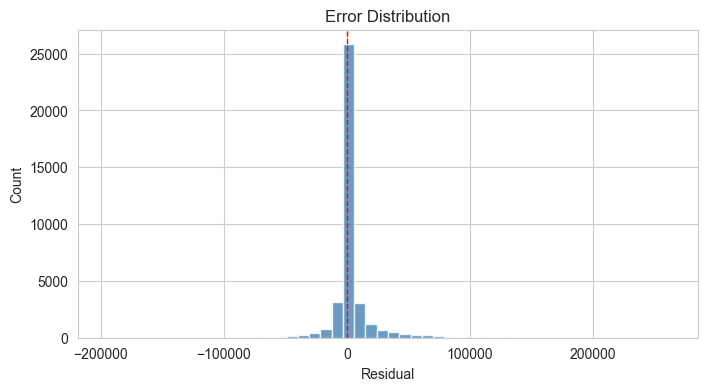

In [9]:
# Actual vs predicted scatter (best model)
plot_actual_vs_predicted(y_test, rf_preds)
plot_residuals(y_test, rf_preds)
plot_error_distribution(y_test, rf_preds)

## Notes
- Random Forest achieves best performance (R² ≈ 0.91) with GridSearchCV tuning
- Linear Regression gives strong baseline (R² ≈ 0.80), confirming good feature engineering
- LSTM captures temporal dependencies (R² ≈ 0.51) but underperforms on this dataset
- Top RF features: UL_bitrate, lag_1, RSRP, Speed — temporal + RF features dominate
- Key insight: 1-second granularity data has strong auto-correlation (0.89), making lag features highly predictive
- Dataset: uccmisl/5Gdataset — real Irish 5G drive tests, ACM MMSys 2020